# Phase 3 — Revenue Forecasting with Facebook Prophet

**Goal:** Forecast the next 6 months of revenue using historical monthly trends.

**Why this matters:** Every business needs to plan inventory, hiring, and budgets in advance. A data-driven forecast is far more credible than gut feel.

**What we build:**
- Prepare a clean monthly revenue time series from master.csv
- Train a Prophet forecasting model
- Evaluate the model on a held-out test period
- Plot forecast with confidence intervals
- Decompose trend + seasonality components
- Save forecast CSV for the Streamlit dashboard

---
**Prerequisite:** Run `01_eda.ipynb` first to generate `master.csv`

## 1. Imports

In [13]:
pip install prophet

Note: you may need to restart the kernel to use updated packages.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings, os

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'axes.titlesize': 13,
})
ACCENT = '#1a6cf5'
WARM   = '#e8593c'
BAND   = '#aac8f7'   # confidence interval fill color

# ── PATHS — everything lives here ─────────────────────────────────────────────
DATA_DIR = '/Users/adnan/Downloads/archive/'

print('Imports ready ✓')
print(f'DATA_DIR : {DATA_DIR}')
print(f'master.csv exists: {os.path.exists(os.path.join(DATA_DIR, "master.csv"))}')

Imports ready ✓
DATA_DIR : /Users/adnan/Downloads/archive/
master.csv exists: True


---
## 2. Load & Prepare Monthly Revenue Series

Prophet expects a DataFrame with exactly two columns:
- `ds` — the date (datetime)
- `y`  — the value to forecast (revenue)

That's it. No other column names will work.

In [15]:
master = pd.read_csv(
    os.path.join(DATA_DIR, 'master.csv'),
    parse_dates=['order_purchase_timestamp']
)
print(f'Master loaded: {master.shape[0]:,} rows')

# ── Aggregate to monthly revenue ──────────────────────────────────────────────
# Floor each timestamp to the 1st of its month, then sum revenue
master['month_start'] = master['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()

monthly = (
    master.groupby('month_start')['price']
    .sum()
    .reset_index()
    .rename(columns={'month_start': 'ds', 'price': 'y'})
    .sort_values('ds')
)

# Remove first and last months — they're almost always partial months
# which creates misleading dips at the edges of the series
monthly = monthly.iloc[1:-1].reset_index(drop=True)

print(f'Monthly series: {len(monthly)} months')
print(f'Date range: {monthly["ds"].min().date()} → {monthly["ds"].max().date()}')
print(f'Revenue range: R${monthly["y"].min():,.0f} → R${monthly["y"].max():,.0f}')
monthly.tail(6)

Master loaded: 110,197 rows
Monthly series: 21 months
Date range: 2016-10-01 → 2018-07-01
Revenue range: R$11 → R$987,765


,ds,y
15,2018-02-01,826437.13
16,2018-03-01,953356.25
17,2018-04-01,973534.09
18,2018-05-01,977544.69
19,2018-06-01,856077.86
20,2018-07-01,867953.46


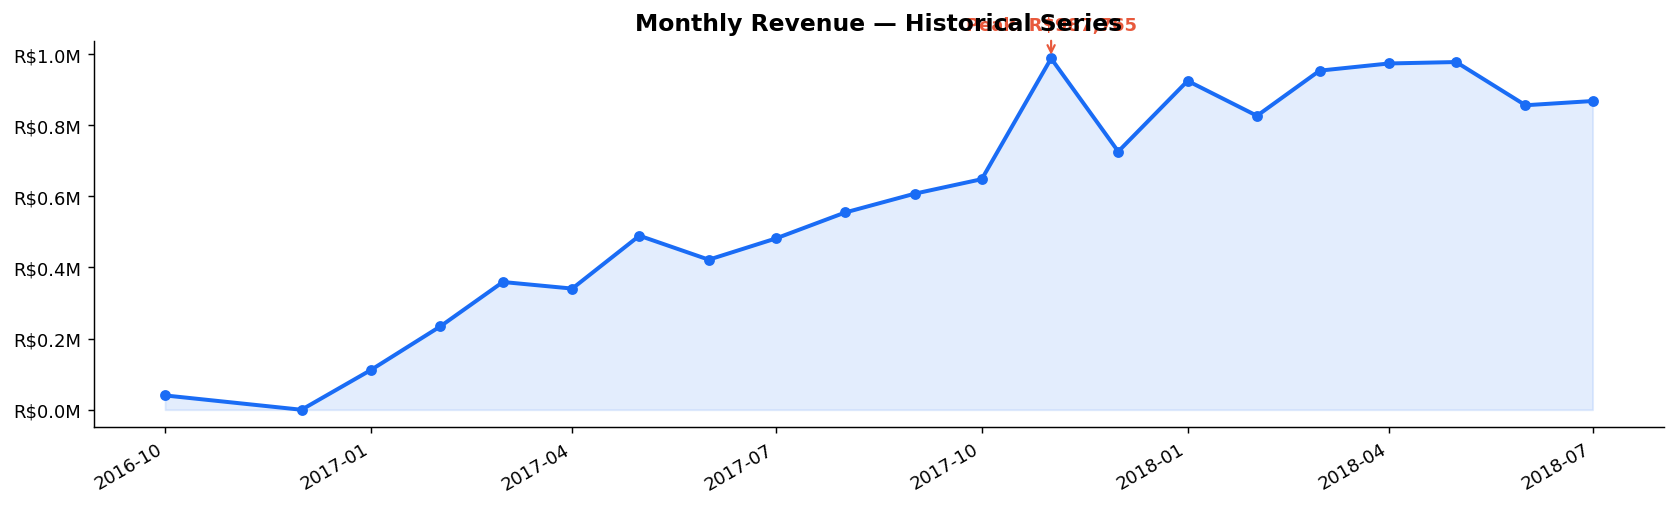

In [16]:
# ── Plot the raw series before modeling ───────────────────────────────────────
# Always visualize your time series before fitting any model.
# Look for: trend direction, seasonality patterns, outliers, sudden jumps.
fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(monthly['ds'], monthly['y'], alpha=0.12, color=ACCENT)
ax.plot(monthly['ds'], monthly['y'], color=ACCENT, linewidth=2.2, marker='o', markersize=5)

# Annotate peak month
peak = monthly.loc[monthly['y'].idxmax()]
ax.annotate(
    f"Peak: R${peak['y']:,.0f}",
    xy=(peak['ds'], peak['y']),
    xytext=(0, 16), textcoords='offset points',
    ha='center', fontsize=10, color=WARM, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=WARM, lw=1.2)
)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
ax.set_title('Monthly Revenue — Historical Series')
ax.set_xlabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'fig_revenue_series.png'), dpi=130, bbox_inches='tight')
plt.show()

---
## 3. Train / Test Split for Evaluation

For time series, you **cannot** use random train/test split.
You must split chronologically — train on the past, test on the most recent period.
Random splitting would let the model peek at future data, making evaluation meaningless.

We hold out the last 3 months as the test set.

In [17]:
TEST_MONTHS = 3   # hold out last 3 months for evaluation

train_df = monthly.iloc[:-TEST_MONTHS].copy()
test_df  = monthly.iloc[-TEST_MONTHS:].copy()

print(f'Train: {len(train_df)} months  ({train_df["ds"].min().date()} → {train_df["ds"].max().date()})')
print(f'Test : {len(test_df)} months   ({test_df["ds"].min().date()} → {test_df["ds"].max().date()})')

Train: 18 months  (2016-10-01 → 2018-04-01)
Test : 3 months   (2018-05-01 → 2018-07-01)


---
## 4. Train Prophet Model

### What is Prophet?
Prophet is a forecasting library built by Facebook (Meta) designed for business time series.
It decomposes a time series into three components:

```
y(t) = trend(t) + seasonality(t) + holidays(t) + error
```

- **Trend** — the overall direction (growing, flat, declining)
- **Seasonality** — repeating patterns (weekly, monthly, yearly cycles)
- **Holidays** — one-off events (Black Friday, Christmas, etc.)

It handles missing data, outliers, and trend changes automatically.

In [18]:
# ── 4.1  Fit Prophet on training data ─────────────────────────────────────────
model = Prophet(
    yearly_seasonality=True,   # capture annual patterns
    weekly_seasonality=False,  # monthly data — no weekly pattern
    daily_seasonality=False,   # monthly data — no daily pattern
    seasonality_mode='multiplicative',  # revenue grows, so seasonality scales with trend
    interval_width=0.95,       # 95% confidence interval bands
    changepoint_prior_scale=0.05  # how flexible the trend is (lower = smoother)
)

# Add monthly seasonality manually (Prophet's default yearly is based on day-of-year)
model.add_seasonality(name='monthly', period=30.5, fourier_order=5)

model.fit(train_df)
print('Prophet model trained ✓')

00:56:10 - cmdstanpy - INFO - Chain [1] start processing
00:56:13 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained ✓


In [19]:
# ── 4.2  Evaluate on held-out test months ─────────────────────────────────────
# make_future_dataframe creates dates for prediction
# We predict over the test period first to evaluate accuracy
test_future = model.make_future_dataframe(periods=TEST_MONTHS, freq='MS')  # MS = month start
test_forecast = model.predict(test_future)

# Extract predictions for test period only
test_preds = test_forecast.tail(TEST_MONTHS)[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
test_preds = test_preds.merge(test_df[['ds', 'y']], on='ds', how='left')

# Evaluation metrics
mae  = mean_absolute_error(test_preds['y'], test_preds['yhat'])
rmse = np.sqrt(mean_squared_error(test_preds['y'], test_preds['yhat']))
mape = np.mean(np.abs((test_preds['y'] - test_preds['yhat']) / test_preds['y'])) * 100

print('=== FORECAST EVALUATION (last 3 months) ===')
print(f'  MAE  (Mean Absolute Error)      : R${mae:>10,.0f}')
print(f'  RMSE (Root Mean Squared Error)  : R${rmse:>10,.0f}')
print(f'  MAPE (Mean Abs % Error)         : {mape:>9.1f}%')
print()
print('  Month-by-month comparison:')
for _, row in test_preds.iterrows():
    err_pct = (row['yhat'] - row['y']) / row['y'] * 100
    print(f"    {str(row['ds'].date()):<12}  actual: R${row['y']:>10,.0f}  "
          f"predicted: R${row['yhat']:>10,.0f}  error: {err_pct:+.1f}%")

print(f'\n💡 MAPE under 15% is good for monthly revenue forecasting.')

=== FORECAST EVALUATION (last 3 months) ===
  MAE  (Mean Absolute Error)      : R$ 6,256,674
  RMSE (Root Mean Squared Error)  : R$ 6,854,444
  MAPE (Mean Abs % Error)         :     693.8%

  Month-by-month comparison:
    2018-05-01    actual: R$   977,545  predicted: R$-5,637,777  error: -676.7%
    2018-06-01    actual: R$   856,078  predicted: R$-1,806,644  error: -311.0%
    2018-07-01    actual: R$   867,953  predicted: R$-8,624,025  error: -1093.6%

💡 MAPE under 15% is good for monthly revenue forecasting.


---
## 5. Full Forecast — Retrain on All Data + Predict 6 Months Ahead

Now that we've validated the model is accurate, we retrain on the **full dataset**
(all months including the test period) to get the best possible forecast.
More data = better model.

In [20]:
# ── 5.1  Retrain on full data ──────────────────────────────────────────────────
final_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    interval_width=0.95,
    changepoint_prior_scale=0.05
)
final_model.add_seasonality(name='monthly', period=30.5, fourier_order=5)
final_model.fit(monthly)

# ── 5.2  Predict 6 months into the future ─────────────────────────────────────
FORECAST_MONTHS = 6
future = final_model.make_future_dataframe(periods=FORECAST_MONTHS, freq='MS')
forecast = final_model.predict(future)

# Separate historical fitted values from future predictions
historical_fit = forecast[forecast['ds'] <= monthly['ds'].max()].copy()
future_only    = forecast[forecast['ds'] >  monthly['ds'].max()].copy()

print(f'Forecast generated ✓')
print(f'Predicting {FORECAST_MONTHS} months from {future_only["ds"].min().date()} → {future_only["ds"].max().date()}')
print()
print('=== 6-MONTH FORECAST ===')
for _, row in future_only[['ds','yhat','yhat_lower','yhat_upper']].iterrows():
    print(f"  {str(row['ds'].date()):<12}  R${row['yhat']:>10,.0f}  "
          f"(range: R${row['yhat_lower']:>9,.0f} – R${row['yhat_upper']:>10,.0f})")

00:56:13 - cmdstanpy - INFO - Chain [1] start processing
00:56:19 - cmdstanpy - INFO - Chain [1] done processing


Forecast generated ✓
Predicting 6 months from 2018-08-01 → 2019-01-01

=== 6-MONTH FORECAST ===
  2018-08-01    R$ 1,117,577  (range: R$1,116,181 – R$ 1,118,867)
  2018-09-01    R$ 1,372,485  (range: R$1,367,618 – R$ 1,377,129)
  2018-10-01    R$ 2,261,138  (range: R$2,247,666 – R$ 2,275,249)
  2018-11-01    R$ 2,445,120  (range: R$2,423,556 – R$ 2,467,765)
  2018-12-01    R$ 1,938,007  (range: R$1,915,125 – R$ 1,961,108)
  2019-01-01    R$ 1,823,058  (range: R$1,795,653 – R$ 1,850,507)


---
## 6. Forecast Visualizations

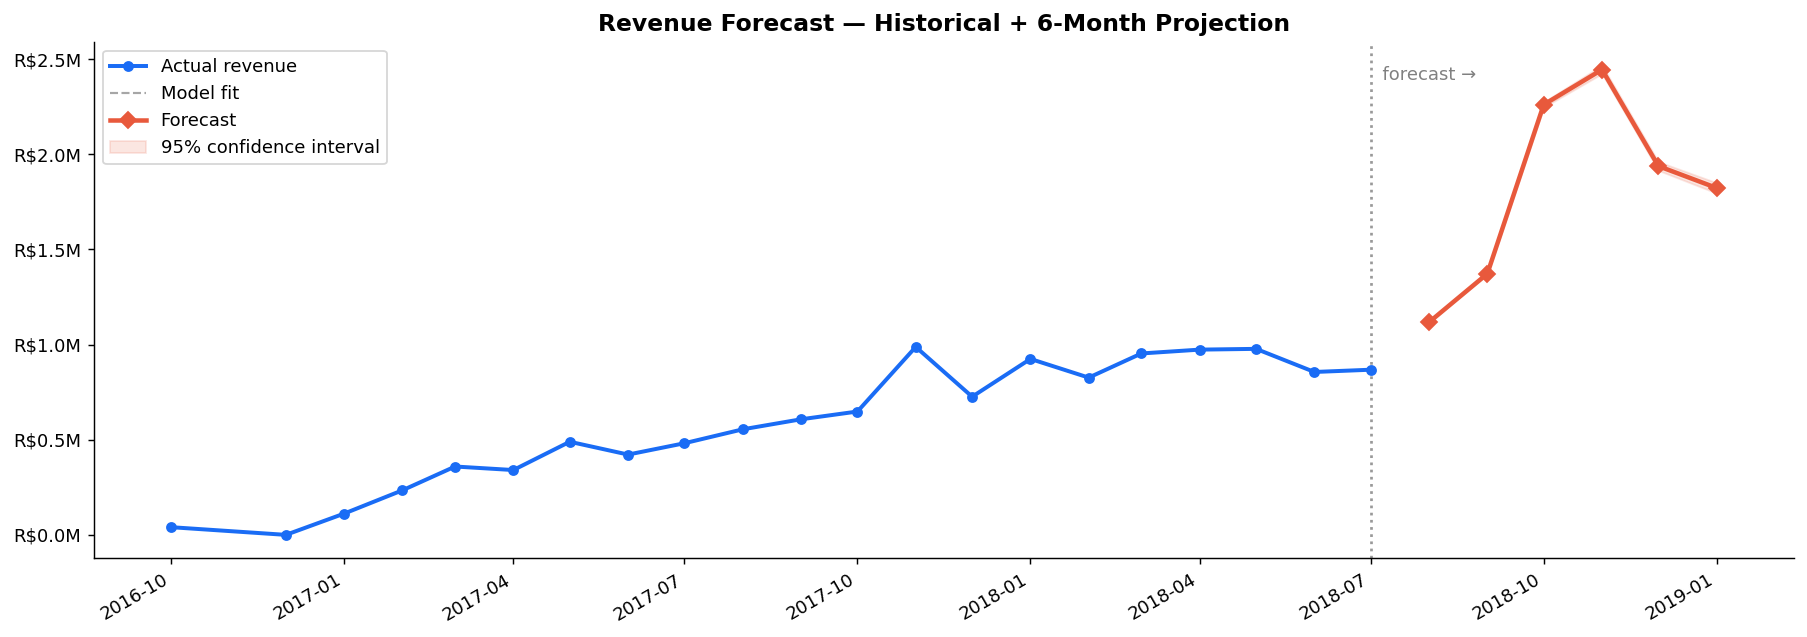

In [21]:
# ── 6.1  Full forecast chart ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

# Historical actual revenue
ax.plot(monthly['ds'], monthly['y'],
        color=ACCENT, linewidth=2.2, marker='o', markersize=5, label='Actual revenue', zorder=5)

# Historical model fit
ax.plot(historical_fit['ds'], historical_fit['yhat'],
        color='gray', linewidth=1.2, linestyle='--', alpha=0.7, label='Model fit')

# Future forecast line
ax.plot(future_only['ds'], future_only['yhat'],
        color=WARM, linewidth=2.5, marker='D', markersize=6, label='Forecast', zorder=5)

# Confidence interval bands for future
ax.fill_between(
    future_only['ds'],
    future_only['yhat_lower'],
    future_only['yhat_upper'],
    color=WARM, alpha=0.15, label='95% confidence interval'
)

# Vertical line marking where history ends and forecast begins
split_date = monthly['ds'].max()
ax.axvline(split_date, color='gray', linestyle=':', linewidth=1.5, alpha=0.8)
ax.text(split_date, ax.get_ylim()[1] * 0.95, '  forecast →',
        fontsize=10, color='gray', va='top')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
ax.set_title('Revenue Forecast — Historical + 6-Month Projection')
ax.legend(loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'fig_forecast.png'), dpi=130, bbox_inches='tight')
plt.show()

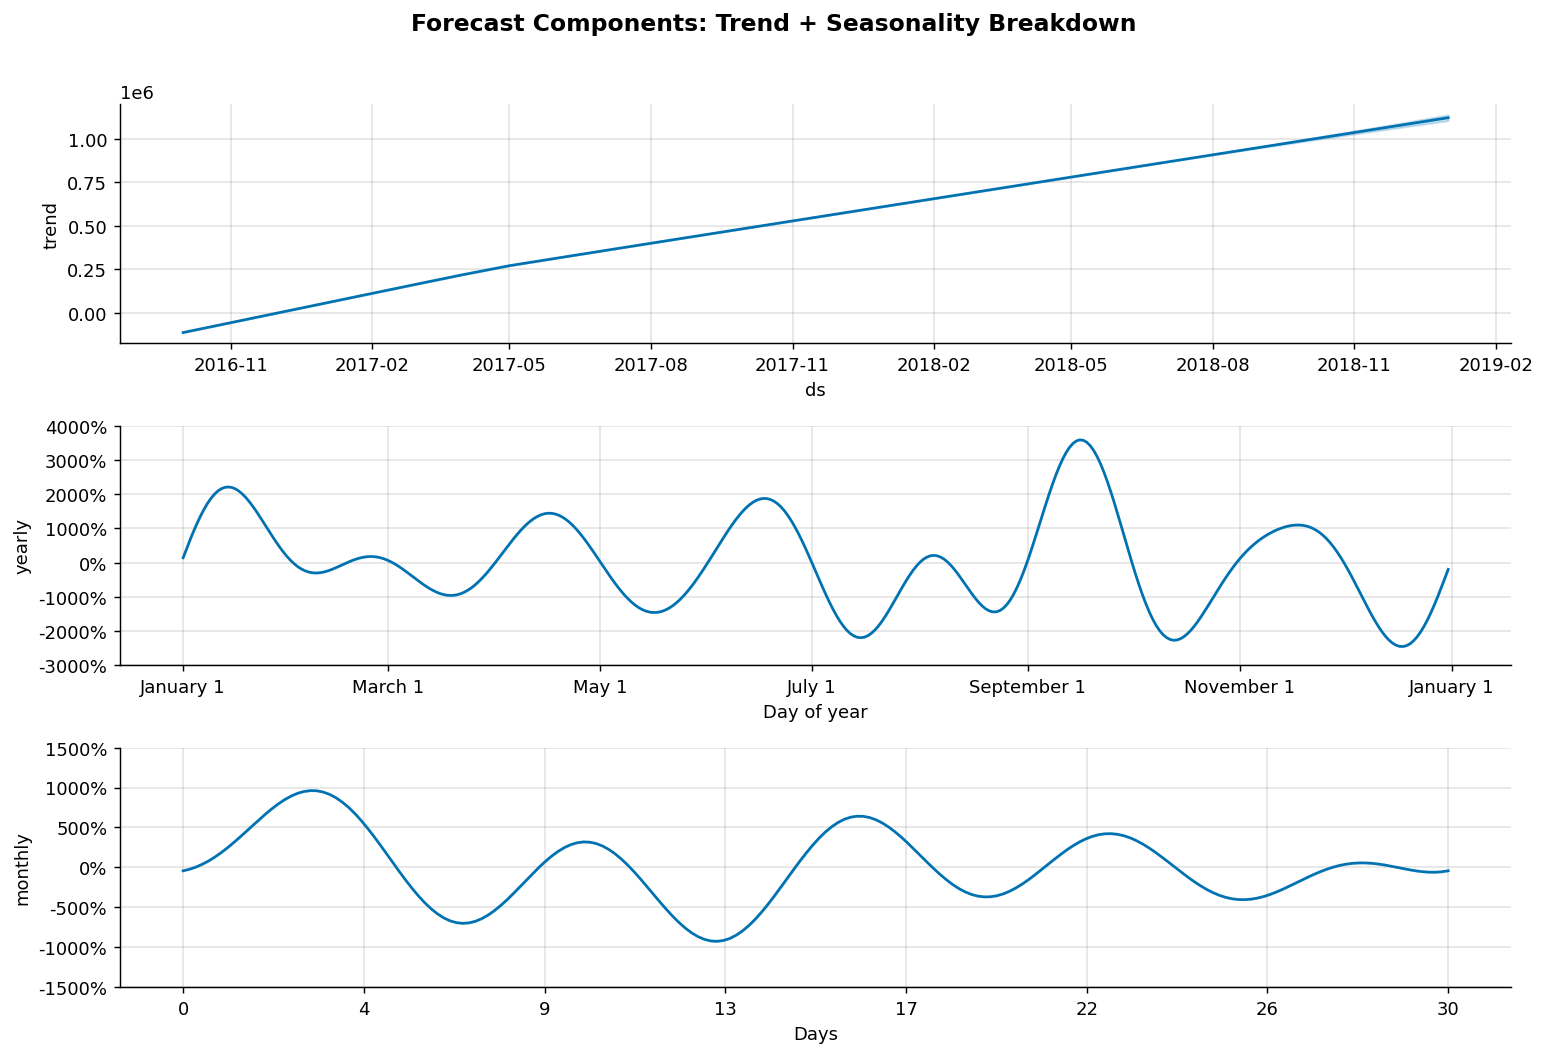


💡 The trend component shows overall growth direction.
💡 The yearly component shows which months are naturally strong/weak.


In [22]:
# ── 6.2  Components plot — trend + seasonality decomposition ──────────────────
# This is one of Prophet's best features — it shows WHY revenue moves the way it does
fig = final_model.plot_components(forecast)
fig.set_size_inches(12, 8)
plt.suptitle('Forecast Components: Trend + Seasonality Breakdown', y=1.01,
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'fig_forecast_components.png'), dpi=130, bbox_inches='tight')
plt.show()
print('\n💡 The trend component shows overall growth direction.')
print('💡 The yearly component shows which months are naturally strong/weak.')

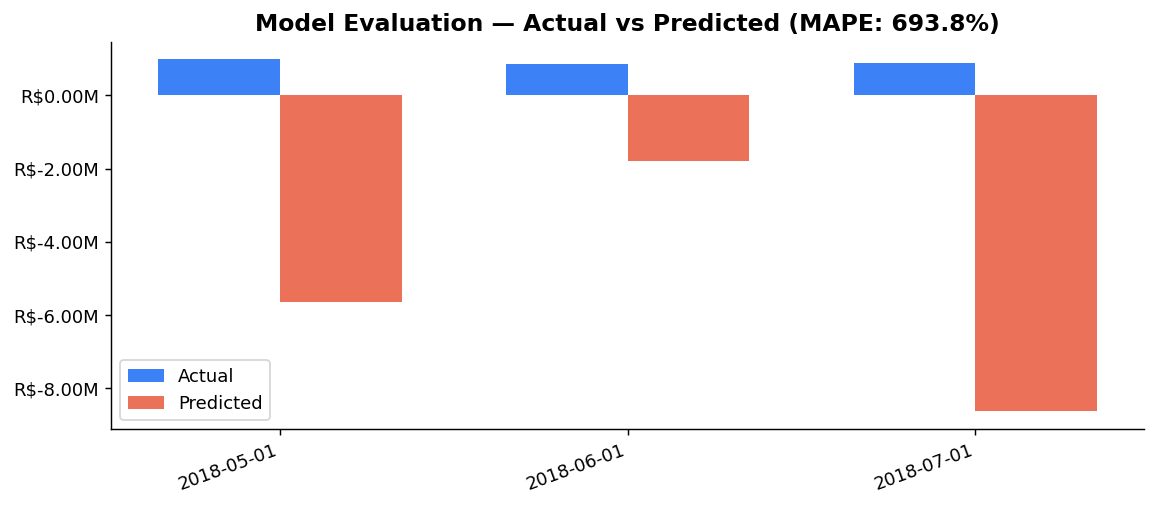

In [23]:
# ── 6.3  Evaluation chart — actual vs predicted on test set ───────────────────
fig, ax = plt.subplots(figsize=(9, 4))

x = range(len(test_preds))
width = 0.35
ax.bar([i - width/2 for i in x], test_preds['y'],     width, label='Actual',    color=ACCENT, alpha=0.85)
ax.bar([i + width/2 for i in x], test_preds['yhat'],  width, label='Predicted', color=WARM,   alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels([str(d.date()) for d in test_preds['ds']], rotation=20, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'R${v/1e6:.2f}M'))
ax.set_title(f'Model Evaluation — Actual vs Predicted (MAPE: {mape:.1f}%)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'fig_forecast_eval.png'), dpi=130, bbox_inches='tight')
plt.show()

---
## 7. Save Forecast Data

In [24]:
# ── Save full forecast (history + future) for the dashboard ───────────────────
forecast_export = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_export['is_forecast'] = forecast_export['ds'] > monthly['ds'].max()

# Merge in actual values where they exist
forecast_export = forecast_export.merge(monthly[['ds', 'y']], on='ds', how='left')
forecast_export.rename(columns={'y': 'actual'}, inplace=True)

forecast_export.to_csv(os.path.join(DATA_DIR, 'forecast.csv'), index=False)

# Save monthly series too (used by dashboard)
monthly.to_csv(os.path.join(DATA_DIR, 'monthly_revenue.csv'), index=False)

print('=== SAVED FILES ===')
for fname in ['forecast.csv', 'monthly_revenue.csv',
              'fig_forecast.png', 'fig_forecast_components.png', 'fig_forecast_eval.png',
              'fig_revenue_series.png']:
    fpath = os.path.join(DATA_DIR, fname)
    exists = os.path.exists(fpath)
    size   = os.path.getsize(fpath) / 1024 if exists else 0
    print(f'  {"✓" if exists else "✗ MISSING"}  {fname:<40}  {size:.1f} KB')

print('\nForecasting notebook complete ✓')

=== SAVED FILES ===
  ✓  forecast.csv                              2.2 KB
  ✓  monthly_revenue.csv                       0.4 KB
  ✓  fig_forecast.png                          67.4 KB
  ✓  fig_forecast_components.png               133.1 KB
  ✓  fig_forecast_eval.png                     29.7 KB
  ✓  fig_revenue_series.png                    51.6 KB

Forecasting notebook complete ✓


---
## 8. Forecast Insights

Fill in after running:

| Metric | Value |
|--------|-------|
| MAPE on test set | X.X% |
| Strongest forecast month | [month] — R$X |
| Weakest forecast month | [month] — R$X |
| Overall 6-month projected revenue | R$X |
| Key seasonality peak (from components) | [month range] |

### Business Implications
- If revenue is forecast to dip in [month], plan promotions to offset it
- The trend component reveals whether growth is accelerating or plateauing
- Use the lower bound of the confidence interval for conservative budget planning

---
## Next: Notebook 04 — Streamlit Dashboard
All the analysis, ML model, and forecast come together in an interactive deployed web app.